### importing

In [1]:

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os

import plotly.express as px
import plotly.graph_objects as go

In [2]:
path = r'C:\Users\moham\Documents\major project\New folder\archive'
files = ['uber-raw-data-aug14.csv',
         'uber-raw-data-apr14.csv',
         'uber-raw-data-jul14.csv',
         'uber-raw-data-jun14.csv',
         'uber-raw-data-may14.csv',
         'uber-raw-data-sep14.csv']
final = pd.DataFrame()

for file in files:
    df = pd.read_csv(path+"/"+file,encoding='utf-8')
    final = pd.concat([final,df])

In [3]:
final.shape

(4534327, 4)

In [4]:
df = final.copy()
df.head(10)

,Date/Time,Lat,Lon,Base
0,8/1/2014 0:03:00,40.7366,-73.9906,B02512
1,8/1/2014 0:09:00,40.7260,-73.9918,B02512
2,8/1/2014 0:12:00,40.7209,-74.0507,B02512
3,8/1/2014 0:12:00,40.7387,-73.9856,B02512
4,8/1/2014 0:12:00,40.7323,-74.0077,B02512
5,8/1/2014 0:13:00,40.7349,-74.0033,B02512
6,8/1/2014 0:15:00,40.7279,-73.9542,B02512
7,8/1/2014 0:17:00,40.7210,-73.9937,B02512
8,8/1/2014 0:19:00,40.7195,-74.0060,B02512
9,8/1/2014 0:20:00,40.7448,-73.9799,B02512


In [5]:
df.dtypes

Date/Time     object
Lat          float64
Lon          float64
Base          object
dtype: object

### visualization

In [6]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%m/%d/%Y %H:%M:%S')
df.dtypes

Date/Time    datetime64[ns]
Lat                 float64
Lon                 float64
Base                 object
dtype: object

In [7]:
df['weekday']=df['Date/Time'].dt.day_name()
df['day']=df['Date/Time'].dt.day
df['minute']=df['Date/Time'].dt.minute
df['month']=df['Date/Time'].dt.month
df['hour']=df['Date/Time'].dt.hour
df.head()

,Date/Time,Lat,Lon,Base,weekday,day,minute,month,hour
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,Friday,1,3,8,0
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,Friday,1,9,8,0
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,Friday,1,12,8,0
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,Friday,1,12,8,0
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,Friday,1,12,8,0


In [8]:
df.tail()

,Date/Time,Lat,Lon,Base,weekday,day,minute,month,hour
1028131,2014-09-30 22:57:00,40.7668,-73.9845,B02764,Tuesday,30,57,9,22
1028132,2014-09-30 22:57:00,40.6911,-74.1773,B02764,Tuesday,30,57,9,22
1028133,2014-09-30 22:58:00,40.8519,-73.9319,B02764,Tuesday,30,58,9,22
1028134,2014-09-30 22:58:00,40.7081,-74.0066,B02764,Tuesday,30,58,9,22
1028135,2014-09-30 22:58:00,40.7140,-73.9496,B02764,Tuesday,30,58,9,22


In [9]:
df.dtypes

Date/Time    datetime64[ns]
Lat                 float64
Lon                 float64
Base                 object
weekday              object
day                   int64
minute                int64
month                 int64
hour                  int64
dtype: object

In [10]:
colors = ['lightslategray',] * 5
colors[0] = 'blue'

fig = go.Figure(data=[go.Bar(
    x=df['weekday'].value_counts().index,
    y=df['weekday'].value_counts().values,
    marker_color=colors # marker color can be a single color value or an iterable
)])
fig.update_layout(title_text='Rush Day of Uber Trip')

In [11]:
colors = ['lightslategray',] * 5
colors[0] = 'blue'

fig = go.Figure(data=[go.Bar(
    x = df['weekday'].value_counts().index,
    y = df['weekday'].value_counts(),
    marker_color=colors # marker color can be a single color value or an iterable
)])
fig.update_layout(title_text='High Sales of Uber Trip')

Text(0.5, 0, 'work hour')

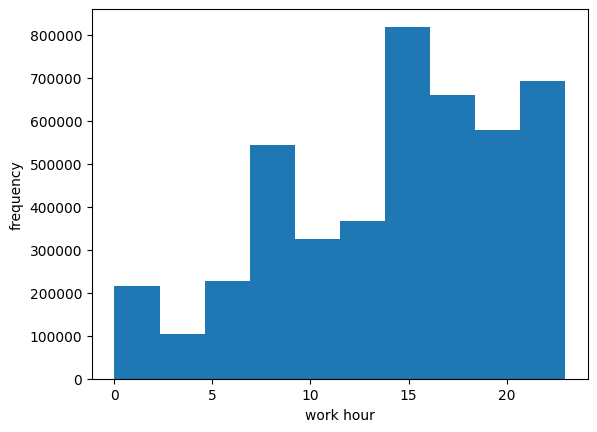

In [12]:
plt.hist(df['hour'])
plt.ylabel('frequency')
plt.xlabel('work hour')

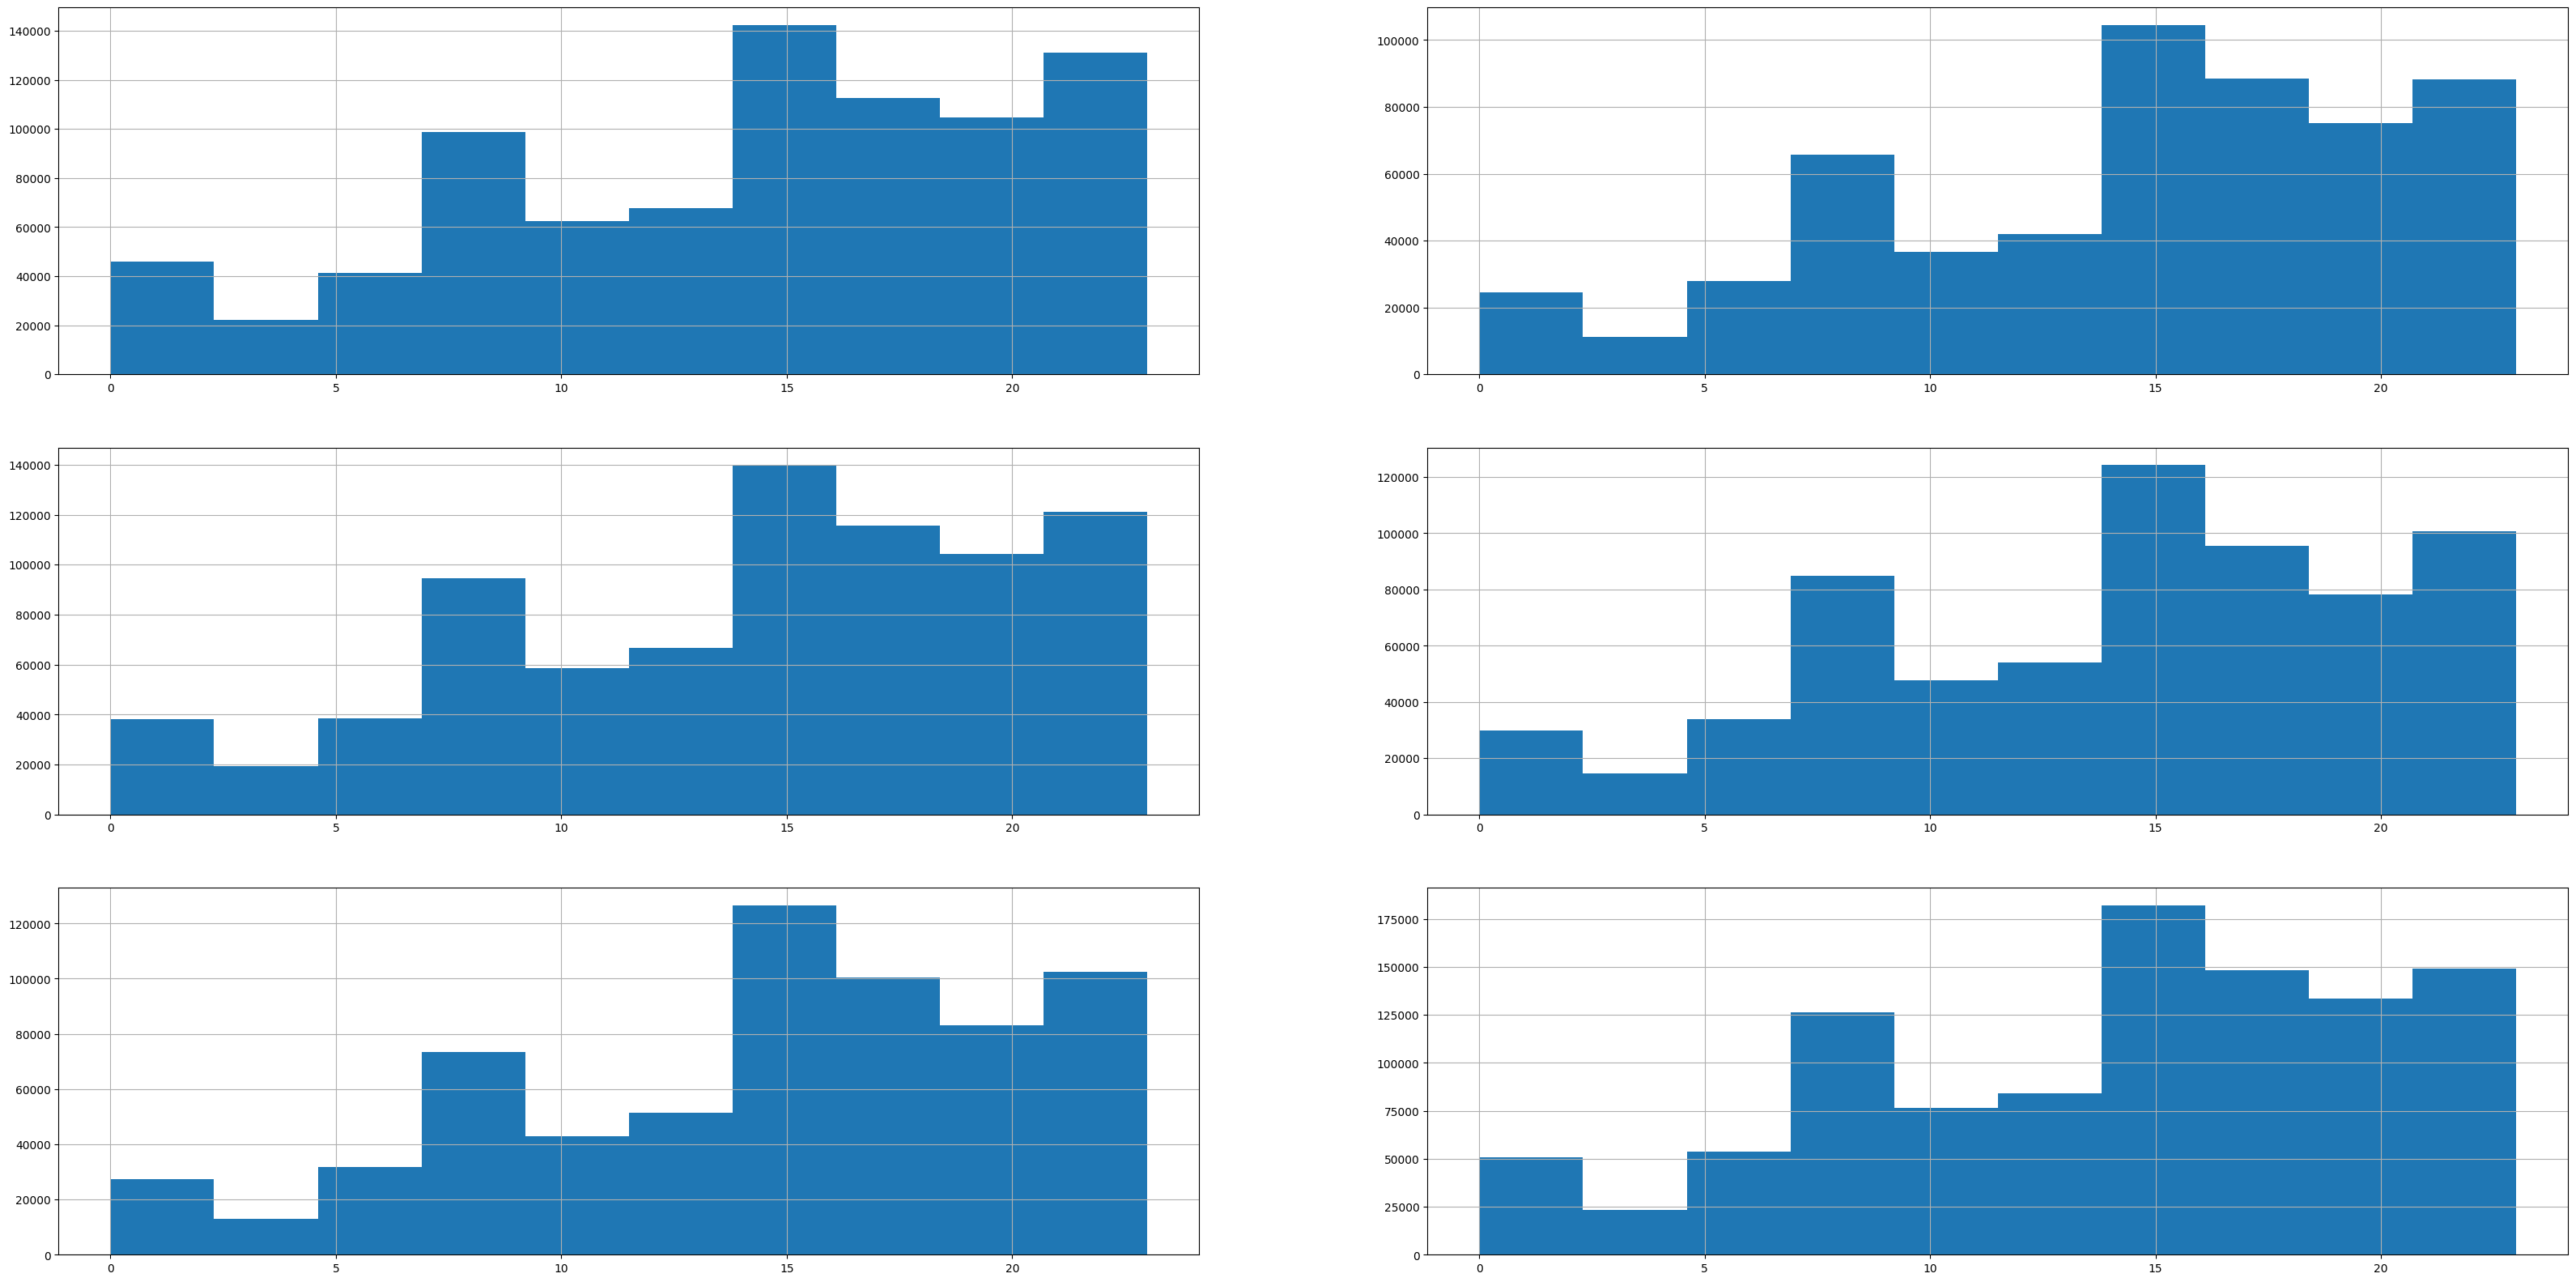

In [13]:
plt.figure(figsize=(40,20))
for i,month in enumerate(df['month'].unique()):
  plt.subplot(3,2,i+1)
  df[df['month']==month]['hour'].hist()

In [14]:
import plotly.graph_objects as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

In [15]:
df.groupby('month')['hour'].count()

month
4     564516
5     652435
6     663844
7     796121
8     829275
9    1028136
Name: hour, dtype: int64

In [16]:
fig = go.Figure(data=[go.Bar(
    x = df.groupby('month')['hour'].count().index,
    y = df.groupby('month')['hour'].count(),
    #marker_color=colors # marker color can be a single color value or an iterable
)])
fig.update_layout(title_text='The Highest Monthly Ride')

Text(0.5, 1.0, 'Journeys by Month Day')

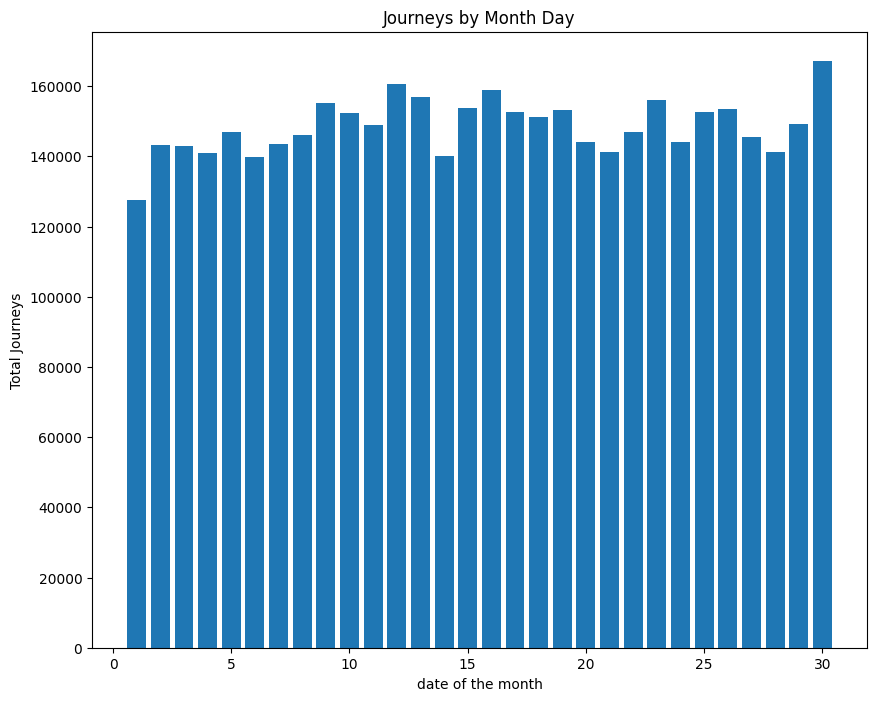

In [17]:
plt.figure(figsize=(10,8))
plt.hist(df['day'],bins=30,rwidth=0.8,range=(0.5,30.5))
plt.xlabel('date of the month')
plt.ylabel('Total Journeys')
plt.title('Journeys by Month Day')

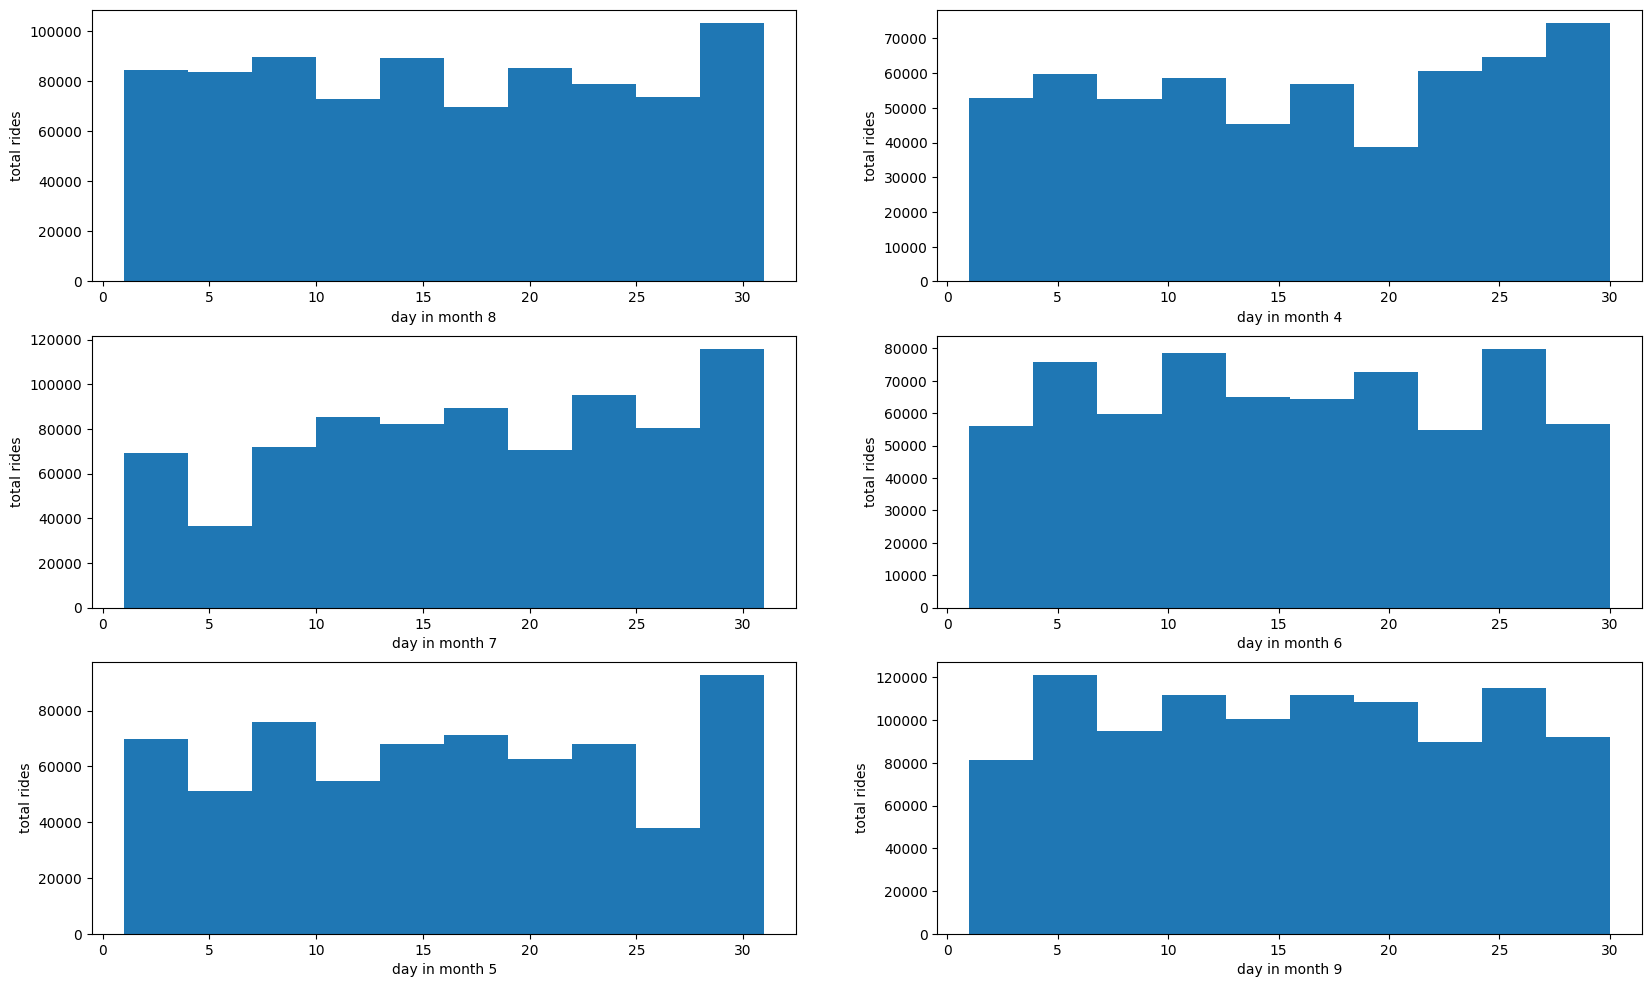

In [18]:
plt.figure(figsize=(20,12))
for i, month in enumerate(df['month'].unique(),1):
  plt.subplot(3,2,i)
  df_out=df[df['month']==month]
  plt.hist(df_out['day'])
  plt.xlabel('day in month {}'.format(month))
  plt.ylabel('total rides')

Text(0.5, 1.0, 'hoursoffday vs latitude of passenger')

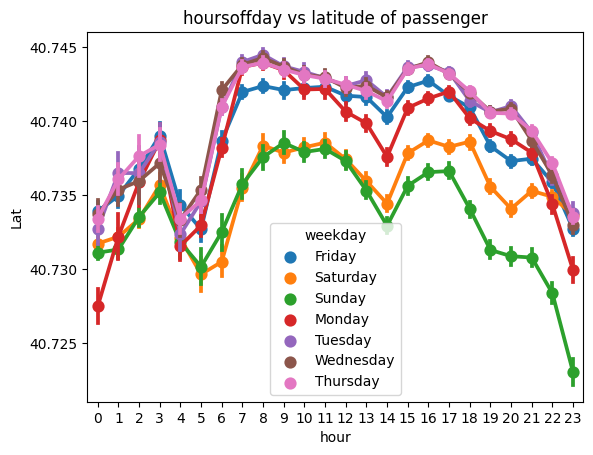

In [19]:
ax=sns.pointplot(x='hour',y='Lat', data=df, hue='weekday')
ax.set_title('hoursoffday vs latitude of passenger')

In [20]:
base=df.groupby(['Base','month'])['Date/Time'].count().reset_index()
base

,Base,month,Date/Time
0,B02512,4,35536
1,B02512,5,36765
2,B02512,6,32509
3,B02512,7,35021
4,B02512,8,31472
5,B02512,9,34370
6,B02598,4,183263
7,B02598,5,260549
8,B02598,6,242975
9,B02598,7,245597


Text(0.5, 1.0, 'Popular Base Number by Month')

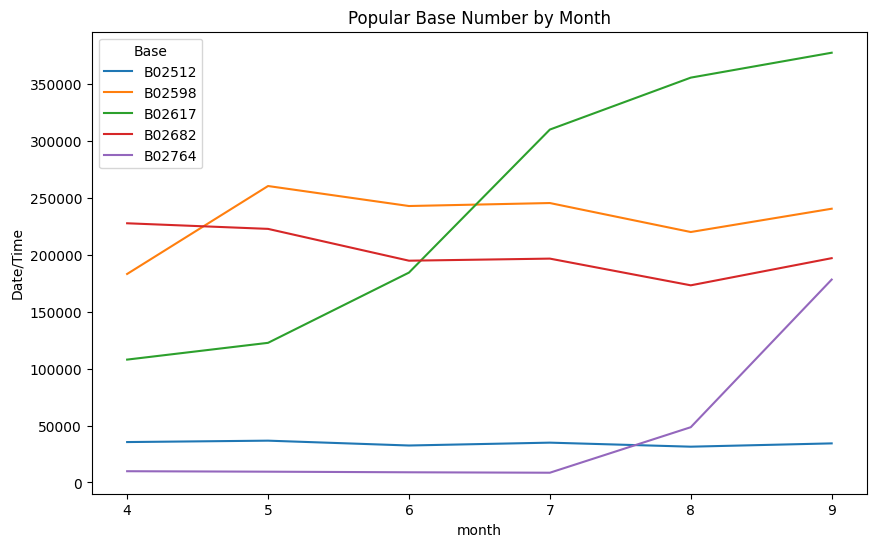

In [21]:
plt.figure(figsize=(10,6))
ax = sns.lineplot(x='month',y='Date/Time', hue='Base',data=base)
ax.set_title('Popular Base Number by Month')

In [22]:
#Heatmap by hour and weekday
def count_rows(rows):
  return len(rows)
by_cross = df.groupby(['weekday','hour']).apply(count_rows)
by_cross

weekday    hour
Friday     0       13716
           1        8163
           2        5350
           3        6930
           4        8806
                   ...  
Wednesday  19      47017
           20      47772
           21      44553
           22      32868
           23      18146
Length: 168, dtype: int64

In [23]:
pivot=by_cross.unstack()
pivot

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
Friday,13716,8163,5350,6930,8806,13450,23412,32061,31509,25230,...,36206,43673,48169,51961,54762,49595,43542,48323,49409,41260
Monday,6436,3737,2938,6232,9640,15032,23746,31159,29265,22197,...,28157,32744,38770,42023,37000,34159,32849,28925,20158,11811
Saturday,27633,19189,12710,9542,6846,7084,8579,11014,14411,17669,...,31418,38769,43512,42844,45883,41098,38714,43826,47951,43174
Sunday,32877,23015,15436,10597,6374,6169,6596,8728,12128,16401,...,28151,31112,33038,31521,28291,25948,25076,23967,19566,12166
Thursday,9293,5290,3719,5637,8505,14169,27065,37038,35431,27812,...,36699,44442,50560,56704,55825,51907,51990,51953,44194,27764
Tuesday,6237,3509,2571,4494,7548,14241,26872,36599,33934,25023,...,34846,41338,48667,55500,50186,44789,44661,39913,27712,14869
Wednesday,7644,4324,3141,4855,7511,13794,26943,36495,33826,25635,...,35148,43388,50684,55637,52732,47017,47772,44553,32868,18146


<Axes: xlabel='hour', ylabel='weekday'>

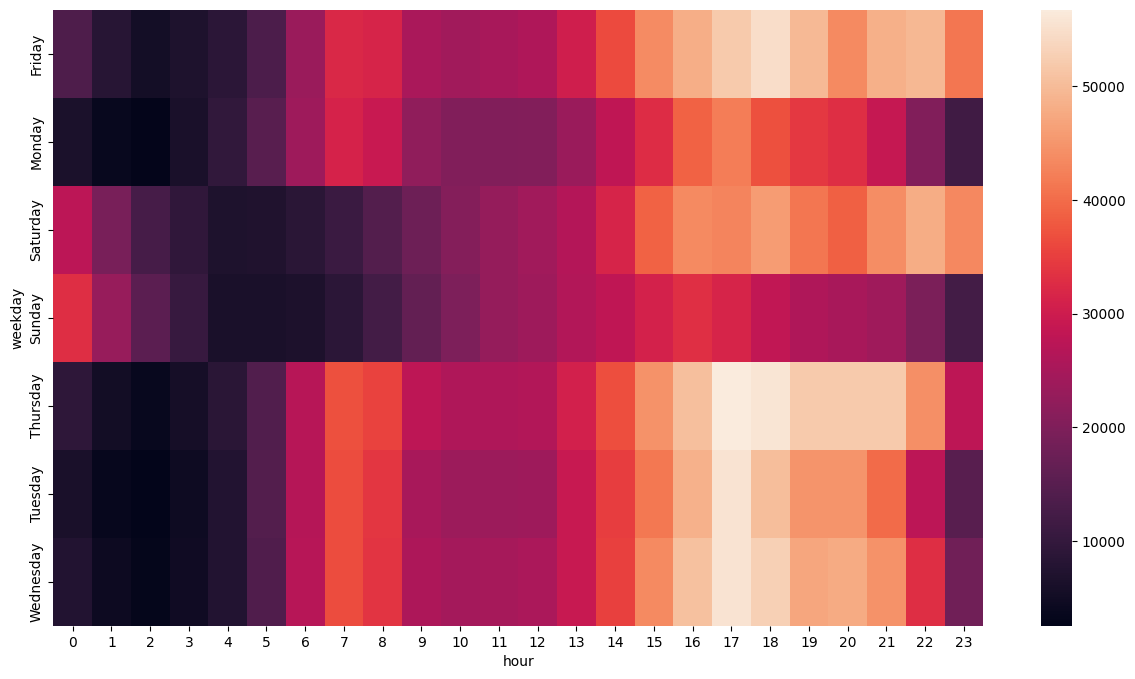

In [24]:
plt.figure(figsize=(15,8))
sns.heatmap(pivot)

In [25]:
#Heatmap by hour and day, month and day, month and weekday
def heatmap(col1, col2):
  by_cross = df.groupby([col1,col2]).apply(count_rows)
  pivot=by_cross.unstack()
  plt.figure(figsize=(15,8))
  return sns.heatmap(pivot)

<Axes: xlabel='hour', ylabel='day'>

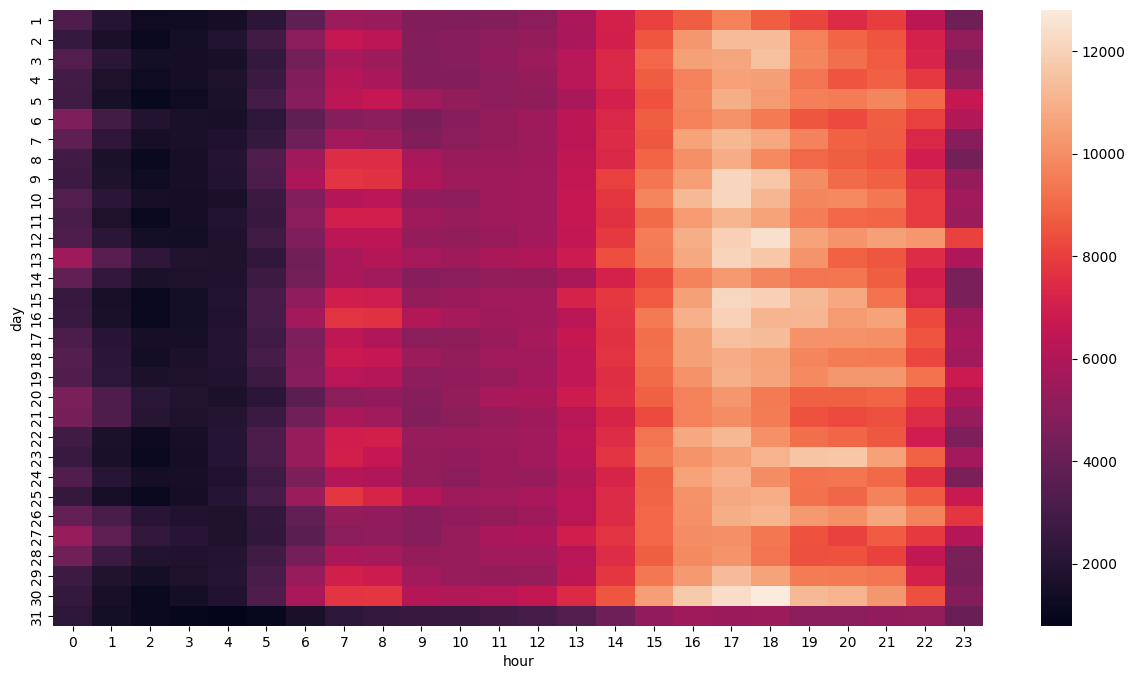

In [26]:
#Heatmap by hour and day
heatmap('day','hour')

<Axes: xlabel='month', ylabel='day'>

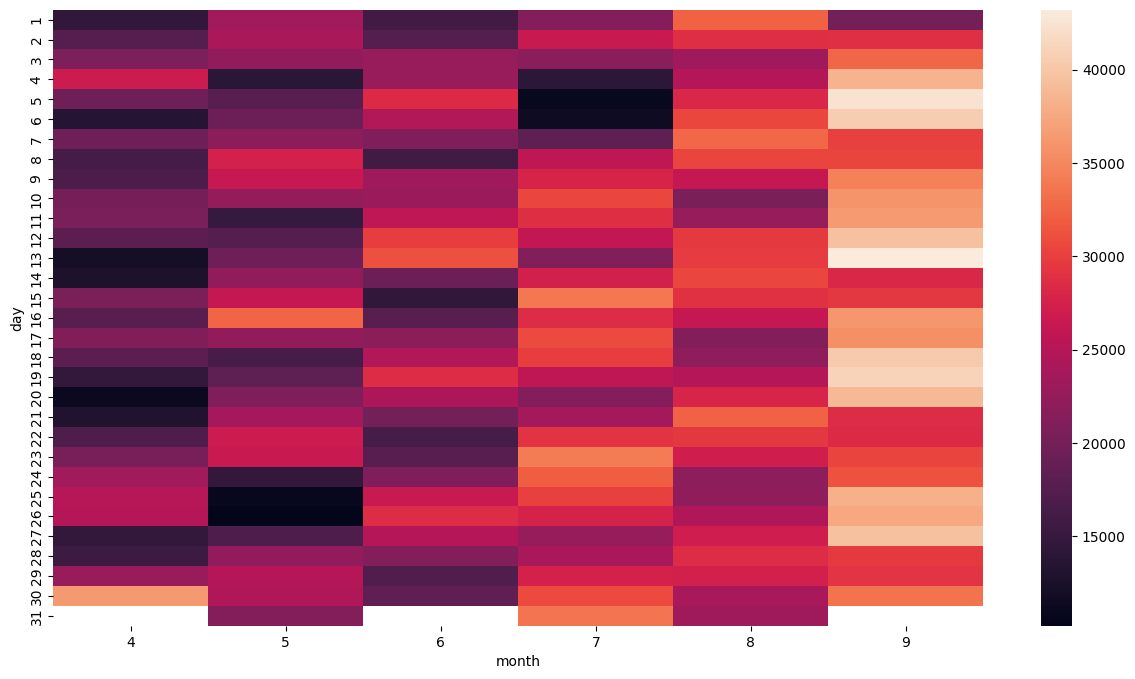

In [27]:
#Heatmap by month and day
heatmap('day','month')

<Axes: xlabel='month', ylabel='weekday'>

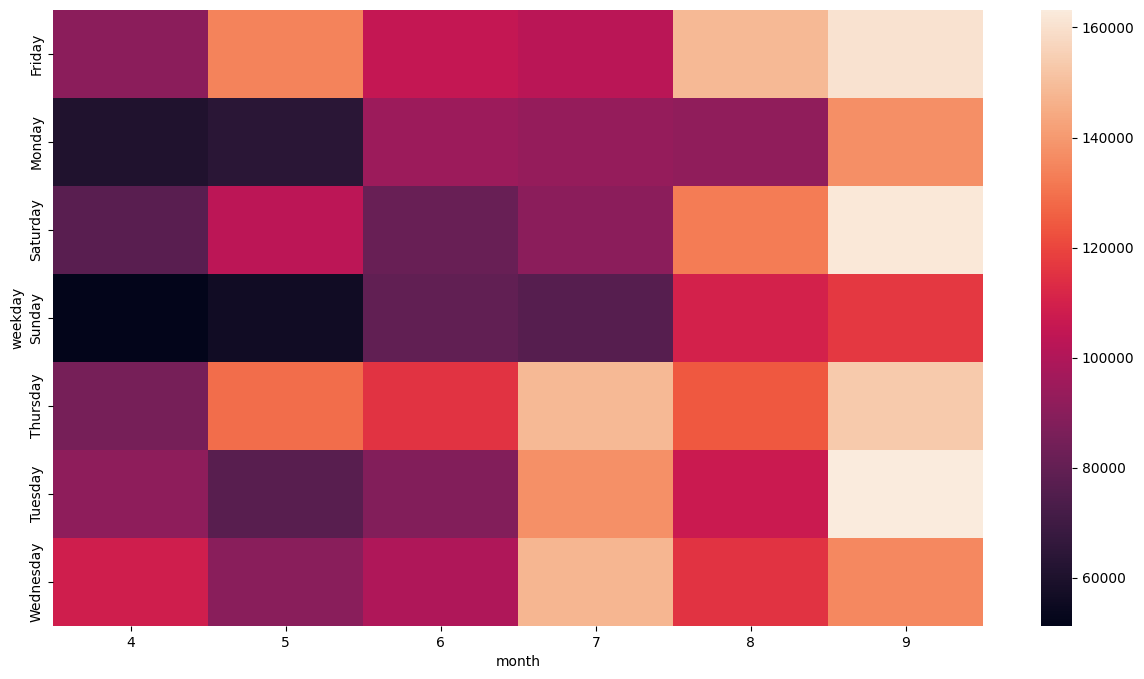

In [28]:
#Heatmap by month and weekday
heatmap('weekday', 'month')

(40.6, 41.0)

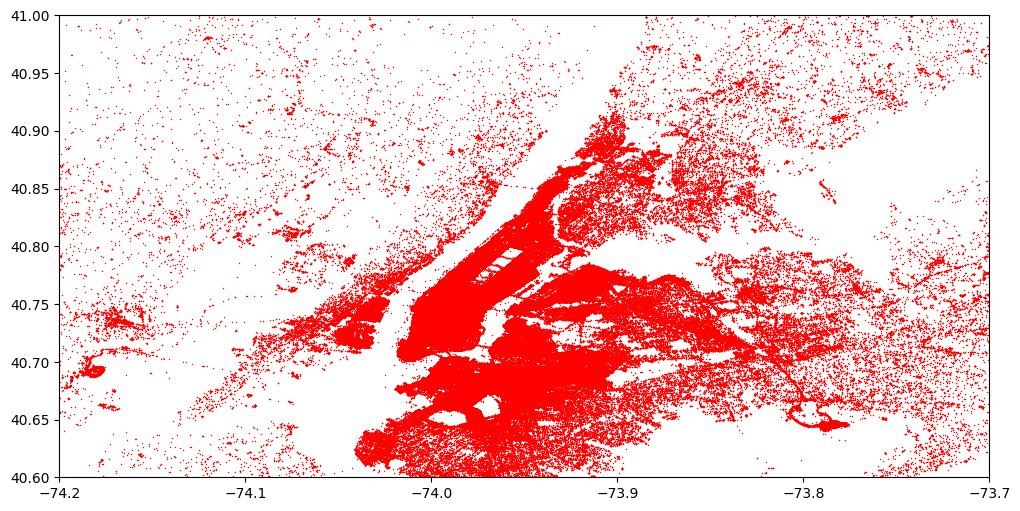

In [29]:
plt.figure(figsize=(12,6))
plt.plot(df['Lon'],df['Lat'],'r+',ms=0.5)
plt.xlim(-74.2,-73.7)
plt.ylim(40.6,41)

In [30]:
df_out=df[df['weekday']=='Sunday']
df_out

,Date/Time,Lat,Lon,Base,weekday,day,minute,month,hour
2404,2014-08-03 00:03:00,40.7488,-74.0273,B02512,Sunday,3,3,8,0
2405,2014-08-03 00:04:00,40.7714,-73.9821,B02512,Sunday,3,4,8,0
2406,2014-08-03 00:06:00,40.7567,-73.9887,B02512,Sunday,3,6,8,0
2407,2014-08-03 00:07:00,40.7176,-73.9576,B02512,Sunday,3,7,8,0
2408,2014-08-03 00:08:00,40.7198,-73.9953,B02512,Sunday,3,8,8,0
...,...,...,...,...,...,...,...,...,...
1014138,2014-09-28 23:57:00,40.6447,-73.7821,B02764,Sunday,28,57,9,23
1014139,2014-09-28 23:57:00,40.7513,-73.9941,B02764,Sunday,28,57,9,23
1014140,2014-09-28 23:57:00,40.6875,-74.1824,B02764,Sunday,28,57,9,23
1014141,2014-09-28 23:57:00,40.6482,-73.7823,B02764,Sunday,28,57,9,23


In [31]:
rush=df_out.groupby(['Lat','Lon'])['weekday'].count().reset_index()
rush.columns=['Lat','Lon','no of trips']
rush

,Lat,Lon,no of trips
0,39.9374,-74.0722,1
1,39.9378,-74.0721,1
2,39.9384,-74.0742,1
3,39.9385,-74.0734,1
4,39.9415,-74.0736,1
...,...,...,...
209225,41.3141,-74.1249,1
209226,41.3180,-74.1298,1
209227,41.3195,-73.6905,1
209228,41.3197,-73.6903,1


In [32]:
df.dtypes

Date/Time    datetime64[ns]
Lat                 float64
Lon                 float64
Base                 object
weekday              object
day                   int64
minute                int64
month                 int64
hour                  int64
dtype: object

In [33]:

df.head()

,Date/Time,Lat,Lon,Base,weekday,day,minute,month,hour
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,Friday,1,3,8,0
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,Friday,1,9,8,0
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,Friday,1,12,8,0
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,Friday,1,12,8,0
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,Friday,1,12,8,0


In [34]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%m/%d/%Y %H:%M:%S')
df.head()

,Date/Time,Lat,Lon,Base,weekday,day,minute,month,hour
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,Friday,1,3,8,0
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,Friday,1,9,8,0
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,Friday,1,12,8,0
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,Friday,1,12,8,0
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,Friday,1,12,8,0


In [35]:
df['weekday']=df['Date/Time'].dt.day_name()

In [36]:
df['day']=df['Date/Time'].dt.day
df['minute']=df['Date/Time'].dt.minute
df['month']=df['Date/Time'].dt.month
df['hour']=df['Date/Time'].dt.hour

In [37]:
df.head()

,Date/Time,Lat,Lon,Base,weekday,day,minute,month,hour
0,2014-08-01 00:03:00,40.7366,-73.9906,B02512,Friday,1,3,8,0
1,2014-08-01 00:09:00,40.7260,-73.9918,B02512,Friday,1,9,8,0
2,2014-08-01 00:12:00,40.7209,-74.0507,B02512,Friday,1,12,8,0
3,2014-08-01 00:12:00,40.7387,-73.9856,B02512,Friday,1,12,8,0
4,2014-08-01 00:12:00,40.7323,-74.0077,B02512,Friday,1,12,8,0


In [38]:
df.tail()

,Date/Time,Lat,Lon,Base,weekday,day,minute,month,hour
1028131,2014-09-30 22:57:00,40.7668,-73.9845,B02764,Tuesday,30,57,9,22
1028132,2014-09-30 22:57:00,40.6911,-74.1773,B02764,Tuesday,30,57,9,22
1028133,2014-09-30 22:58:00,40.8519,-73.9319,B02764,Tuesday,30,58,9,22
1028134,2014-09-30 22:58:00,40.7081,-74.0066,B02764,Tuesday,30,58,9,22
1028135,2014-09-30 22:58:00,40.7140,-73.9496,B02764,Tuesday,30,58,9,22


In [39]:
px.bar(x=df['month'].value_counts().index,
       y=df['month'].value_counts())

Text(0.5, 1.0, 'Rush in New York City')

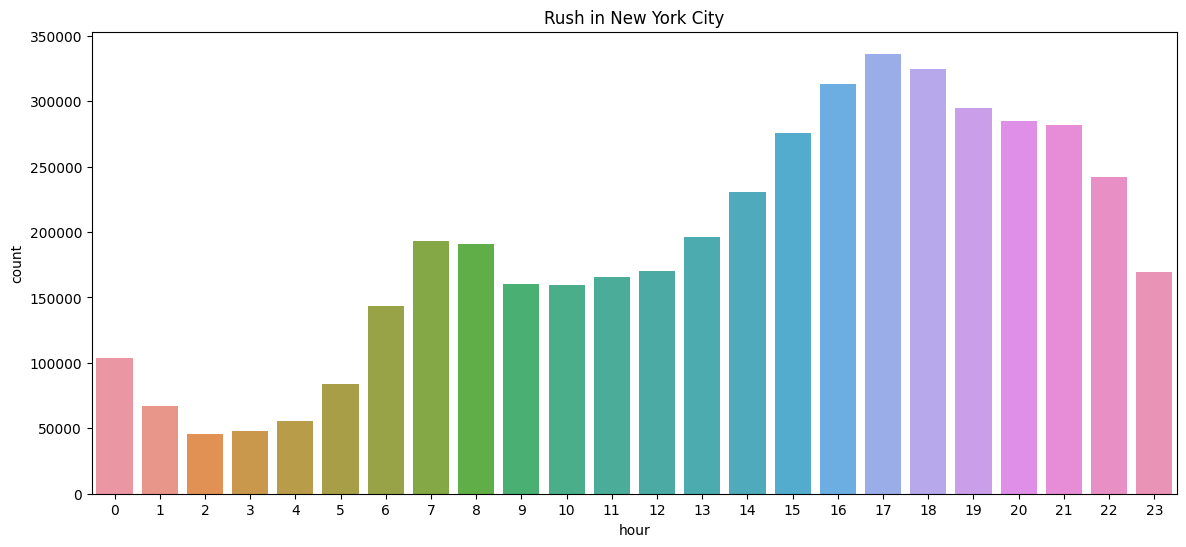

In [40]:
plt.figure(figsize=(14,6))
sns.countplot(x='hour', data=df)
plt.title("Rush in New York City")

In [41]:
summary=df.groupby(['weekday','hour'])['Date/Time'].count().reset_index()
summary

,weekday,hour,Date/Time
0,Friday,0,13716
1,Friday,1,8163
2,Friday,2,5350
3,Friday,3,6930
4,Friday,4,8806
...,...,...,...
163,Wednesday,19,47017
164,Wednesday,20,47772
165,Wednesday,21,44553
166,Wednesday,22,32868


In [42]:
summary.columns=['weekday','hour','count']
summary.head()

,weekday,hour,count
0,Friday,0,13716
1,Friday,1,8163
2,Friday,2,5350
3,Friday,3,6930
4,Friday,4,8806


<Axes: xlabel='hour', ylabel='count'>

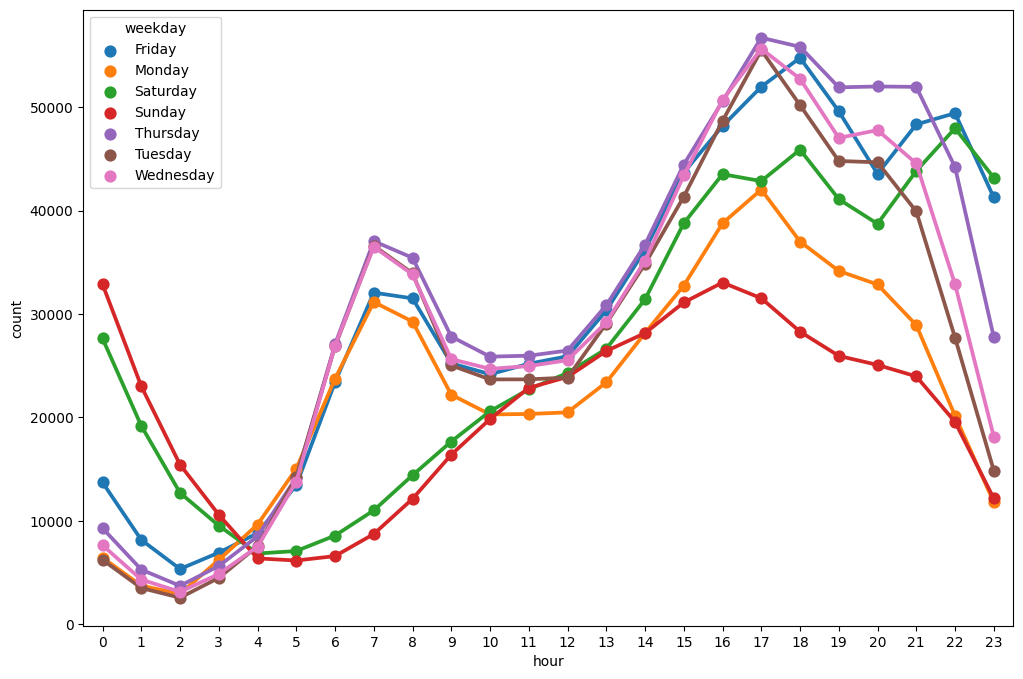

In [43]:
plt.figure(figsize=(12,8))
sns.pointplot(x='hour',y='count',hue='weekday',data=summary)

In [44]:
df['Base'].unique()

array(['B02512', 'B02598', 'B02617', 'B02682', 'B02764'], dtype=object)

### Modeling


### KMedoids Clustering

In [45]:
from sklearn_extra.cluster import KMedoids

In [46]:
kmedoids = KMedoids(n_clusters=5, random_state=0)
clus=df[['Lat','Lon']]
clus

,Lat,Lon
0,40.7366,-73.9906
1,40.7260,-73.9918
2,40.7209,-74.0507
3,40.7387,-73.9856
4,40.7323,-74.0077
...,...,...
1028131,40.7668,-73.9845
1028132,40.6911,-74.1773
1028133,40.8519,-73.9319
1028134,40.7081,-74.0066


In [47]:
cluster1=clus[:10000]
cluster1

,Lat,Lon
0,40.7366,-73.9906
1,40.7260,-73.9918
2,40.7209,-74.0507
3,40.7387,-73.9856
4,40.7323,-74.0077
...,...,...
9995,40.7898,-73.9795
9996,40.7689,-73.8622
9997,40.7427,-73.9920
9998,40.7817,-73.9847


In [48]:
kmedoids.fit(cluster1)

KMedoids(n_clusters=5, random_state=0)

In [49]:
medoid = kmedoids.cluster_centers_
medoid

array([[ 40.7202, -73.9842],
       [ 40.7665, -73.9706],
       [ 40.7481, -73.9892],
       [ 40.7229, -74.0079],
       [ 40.7508, -73.8475]])

In [50]:
dlocation=pd.DataFrame(medoid,columns=['Latitude','Longitude'])
dlocation

,Latitude,Longitude
0,40.7202,-73.9842
1,40.7665,-73.9706
2,40.7481,-73.9892
3,40.7229,-74.0079
4,40.7508,-73.8475


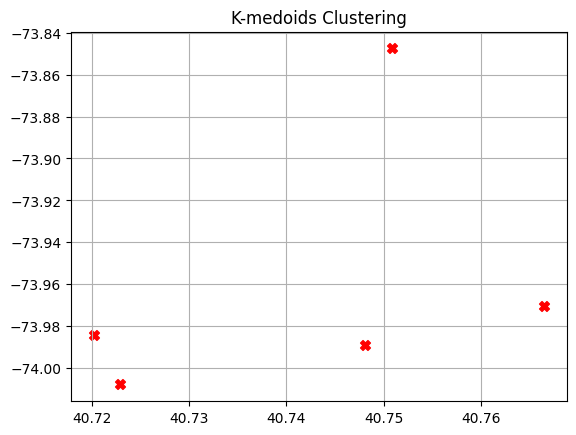

In [51]:

plt.grid(zorder=0)
plt.scatter(dlocation['Latitude'], dlocation['Longitude'],marker="X",c='Red',s=50)
plt.title('K-medoids Clustering')
plt.show()

In [52]:
new_points = [[	40.7481,	-73.9892]]  # New location points to be predicted
cluster_labels = kmedoids.predict(new_points)
cluster_labels

array([2], dtype=int64)

### Gaussian Mixture Models

In [53]:
from sklearn.mixture import GaussianMixture



In [54]:
gmm = GaussianMixture(n_components=5)


In [55]:
gmm.fit(cluster1)

GaussianMixture(n_components=5)

In [56]:
cluster_centers = gmm.means_
cluster_centers 

array([[ 40.74766092, -73.98695535],
       [ 40.78538523, -73.92926581],
       [ 40.73620112, -73.95310165],
       [ 40.66561738, -73.95465648],
       [ 40.57813631, -73.93459942]])

In [57]:
elocation=pd.DataFrame(cluster_centers ,columns=['Latitude','Longitude'])
elocation

,Latitude,Longitude
0,40.747661,-73.986955
1,40.785385,-73.929266
2,40.736201,-73.953102
3,40.665617,-73.954656
4,40.578136,-73.934599


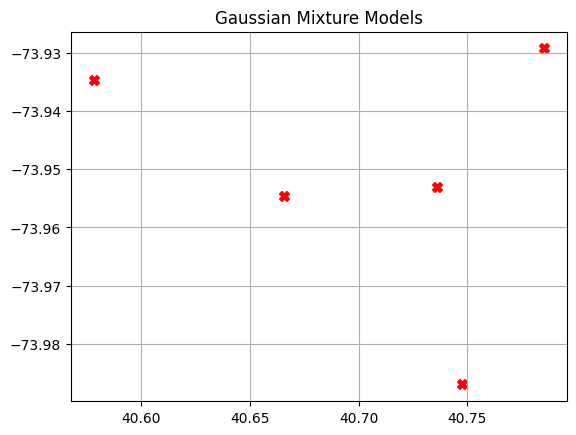

In [58]:
plt.grid(zorder=0)
plt.scatter(elocation['Latitude'],elocation['Longitude'],marker="X",c='Red',s=50)
plt.title('Gaussian Mixture Models')
plt.show()

In [59]:
new_point = [[ 40.221472,	-74.035064]]  # New data point to be predicted
cluster_label = gmm.predict(new_point)
cluster_label

C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:439: UserWarning:

X does not have valid feature names, but GaussianMixture was fitted with feature names



array([4], dtype=int64)


### Agglomerative Clustering

In [60]:
from sklearn.cluster import AgglomerativeClustering

In [61]:
n_clusters = 5  # Number of clusters
agglomerative = AgglomerativeClustering(n_clusters=n_clusters)

In [70]:
agglomerative.fit(cluster1)
labels = agglomerative.labels_


In [71]:
cluster_centers_ = []
for label in range(n_clusters):
    cluster_points = cluster1[labels == label]
    cluster_center = cluster_points.mean(axis=0)
    cluster_centers_.append(cluster_center)
cluster_centers_ = np.array(cluster_centers_)
cluster_centers_

array([[ 40.74530451, -73.98472617],
       [ 40.7992705 , -73.84739896],
       [ 40.66941683, -73.7351589 ],
       [ 40.23112326, -74.04304884],
       [ 40.71040827, -74.21076024]])

In [72]:
glocation=pd.DataFrame(cluster_centers_,columns=['Latitude','Longitude'])
glocation

,Latitude,Longitude
0,40.745305,-73.984726
1,40.799270,-73.847399
2,40.669417,-73.735159
3,40.231123,-74.043049
4,40.710408,-74.210760


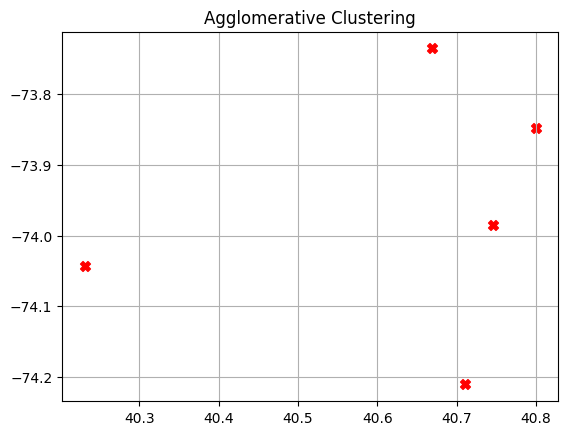

In [73]:
plt.grid(zorder=0)
plt.scatter(glocation['Latitude'],glocation['Longitude'],marker="X",c='Red',s=50)
plt.title('Agglomerative Clustering')
plt.show()

### KMeans Algorithm

In [74]:
from sklearn.cluster import KMeans


In [75]:
Km = KMeans(n_clusters=5,random_state=0)
clus=df[['Lat','Lon']]
clus

,Lat,Lon
0,40.7366,-73.9906
1,40.7260,-73.9918
2,40.7209,-74.0507
3,40.7387,-73.9856
4,40.7323,-74.0077
...,...,...
1028131,40.7668,-73.9845
1028132,40.6911,-74.1773
1028133,40.8519,-73.9319
1028134,40.7081,-74.0066


In [76]:
cluster1=clus[:10000]
cluster1

,Lat,Lon
0,40.7366,-73.9906
1,40.7260,-73.9918
2,40.7209,-74.0507
3,40.7387,-73.9856
4,40.7323,-74.0077
...,...,...
9995,40.7898,-73.9795
9996,40.7689,-73.8622
9997,40.7427,-73.9920
9998,40.7817,-73.9847


In [77]:
y_predict=Km.fit_predict(clus)

C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [78]:
y_predict

array([0, 0, 0, ..., 2, 0, 0])

In [79]:
df['cluster']=y_predict


In [80]:
centroids=Km.cluster_centers_
centroids

array([[ 40.71595848, -73.98970502],
       [ 40.6657894 , -73.76422786],
       [ 40.79668901, -73.87940953],
       [ 40.76228743, -73.97693504],
       [ 40.69502745, -74.20164813]])

In [81]:
clocation=pd.DataFrame(centroids,columns=['Latitude','Longitude'])
clocation

,Latitude,Longitude
0,40.715958,-73.989705
1,40.665789,-73.764228
2,40.796689,-73.879410
3,40.762287,-73.976935
4,40.695027,-74.201648


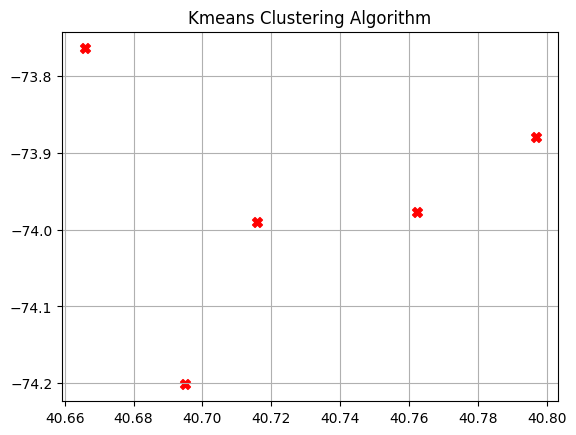

In [82]:
plt.grid(zorder=0)
plt.scatter(clocation['Latitude'],clocation['Longitude'],marker="X",c='Red',s=50)
plt.title('Kmeans Clustering Algorithm')
plt.show()

In [83]:
import folium

In [84]:
map = folium.Map(location=[clocation.Latitude.mean(), clocation.Longitude.mean()], zoom_start=10, control_scale=True)

In [85]:
for index, location_info in clocation.iterrows():
    folium.Marker([location_info["Latitude"], location_info["Longitude"]], popup=location_info).add_to(map)

In [90]:
map

In [87]:
new_location= [(40.7898, -73.9795)]
Km.predict(new_location)

C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:439: UserWarning:

X does not have valid feature names, but KMeans was fitted with feature names



array([3])